# Третья лабораторная работа

## Линейная регрессия и регуляризация

В этой лабораторной работе мы реализуем линейную регрессию и методы регуляризации на примере данных по автомобилям.

## Установка и импорт необходимых библиотек

In [2]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

## Загрузка и подготовка данных

Загрузим подготовленный датасет и выделим числовые признаки для задачи регрессии.

In [4]:
df = pd.read_csv('cars_moldova_clean.csv', delimiter=',')
num_columns = ['Year', 'Distance', 'Engine_capacity(cm3)', 'Price(euro)', 'km_year']
df_num = df[num_columns].copy()
X = df_num.drop(columns=['Price(euro)']).values
y = df_num['Price(euro)'].values
features_names = df_num.drop(columns=['Price(euro)']).columns
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Реализация линейной регрессии вручную

Опишем основные функции для расчёта предсказания, ошибки и градиента.

In [5]:
def forward(weights, inputs):
    return inputs.dot(weights.T)

def loss_func(predicts, labels):
    return np.square(predicts - labels)

def grad_loss(predicts, labels, inputs):
    return 2 * (predicts - labels) * inputs / inputs.size

def update_weights(grad, weights, lr):
    return weights - lr * grad

def weights_init(size, random_state=42):
    np.random.seed(random_state)
    return np.random.randn(size) / np.sqrt(size)

## Обучение модели градиентным спуском

Реализуем цикл обучения, где веса обновляются по градиенту ошибки.

In [6]:
def fit(X, y, weights, lr, epochs=100):
    cost = np.zeros(epochs)
    for i in range(epochs):
        grad = np.zeros(weights.shape)
        loss = 0
        for m in range(X.shape[0]):
            yhat = forward(weights, X[m, :])
            grad += grad_loss(yhat, y[m], X[m, :])
            loss += loss_func(yhat, y[m])
        weights = update_weights(grad / X.shape[0], weights, lr)
        cost[i] = loss / X.shape[0]
    return weights, cost

## Визуализация процесса обучения

Построим график функции потерь по эпохам, чтобы оценить сходимость.

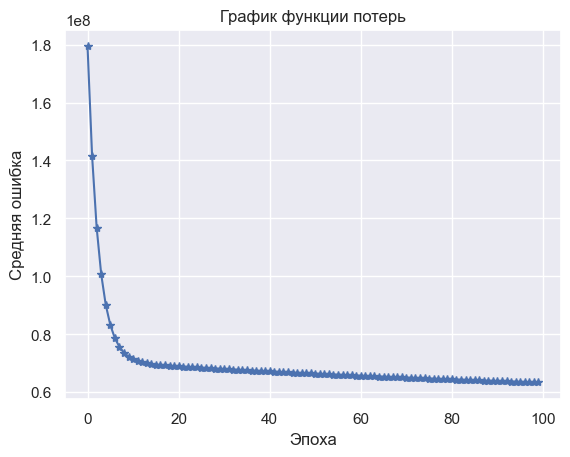

In [7]:
weights = weights_init(X_train.shape[1], random_state=42)
weights, cost = fit(X_train, y_train, weights, lr=0.5, epochs=100)
plt.plot(cost, '-*')
plt.title('График функции потерь')
plt.xlabel('Эпоха')
plt.ylabel('Средняя ошибка')
plt.show()

## Оценка качества модели

Введём метрику R2 для оценки качества предсказания на тестовой выборке.

In [8]:
def predict(weights, inputs):
    return np.array([forward(weights, x) for x in inputs])

def r2_score(weights, inputs, labels):
    predicts = predict(weights, inputs)
    return 1 - np.sum(np.square(labels - predicts)) / np.sum(np.square(labels - np.mean(labels)))

yhat = predict(weights, X_test)
print('R2 на тесте:', r2_score(weights, X_test, y_test))

R2 на тесте: 0.2864812935596258


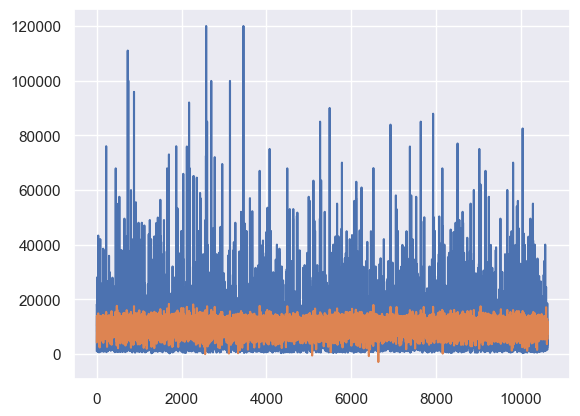

In [9]:
plt.plot(y_test, label='original')
plt.plot(yhat, label='predicted');

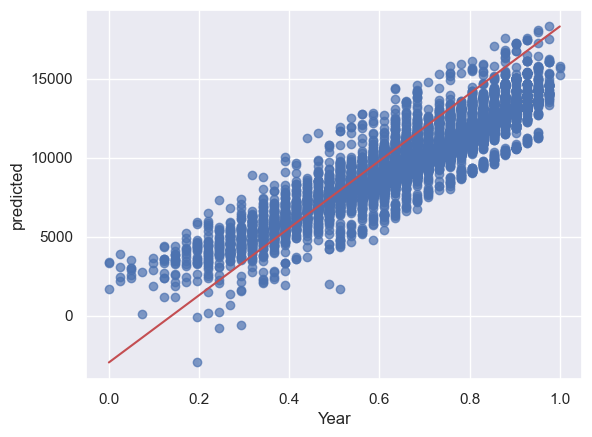

In [29]:
plt.scatter(X_test[:,0], yhat, alpha=0.7)
plt.plot([X_test[:,0].min(), X_test[:,0].max()], [yhat.min(), yhat.max()], 'r')
plt.xlabel(features_names[0])
plt.ylabel('predicted');

## Реализация регуляризации (L2, L1, ElasticNet)

Регуляризация помогает избежать переобучения, добавляя штраф за слишком большие веса модели.

**L2 (Ridge):** штрафует сумму квадратов весов, сглаживает модель, хорошо работает при наличии коррелирующих признаков.

**L1 (Lasso):** штрафует сумму абсолютных значений весов, может занулять некоторые веса, что приводит к отбору признаков.

**ElasticNet:** сочетает оба подхода, полезно при большом количестве признаков и сильной корреляции между ними.

Ниже реализованы простые классы для каждой регуляризации. В комментариях отмечены ключевые моменты.

In [11]:

class RidgeRegression:
    def __init__(self, lr=0.5, l2_penalty=0.001, epochs=100):
        self.lr = lr
        self.l2_penalty = l2_penalty
        self.epochs = epochs
        self.cost = None

    def fit(self, X, y):
        weights = weights_init(X.shape[1])
        cost = np.zeros(self.epochs)
        for i in range(self.epochs):
            grad = np.zeros(weights.shape)
            loss = 0
            for m in range(X.shape[0]):
                yhat = forward(weights, X[m, :])
                grad += grad_loss(yhat, y[m], X[m, :])
                loss += loss_func(yhat, y[m])
            l2_term = self.l2_penalty * weights
            weights = update_weights(grad / X.shape[0] + l2_term, weights, self.lr)
            cost[i] = loss / X.shape[0]
        self.weights = weights
        self.cost = cost

    def predict(self, X):
        return predict(self.weights, X)

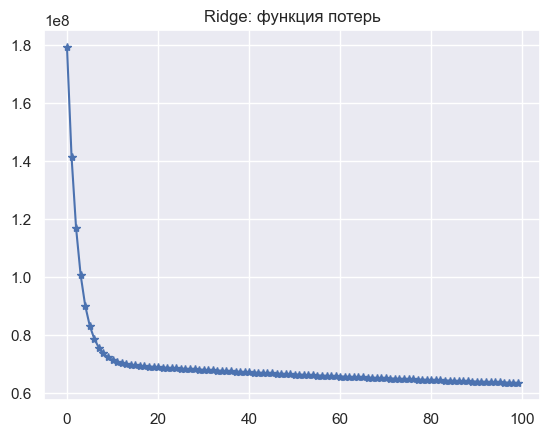

R2 Ridge: 0.2848405402515326


In [12]:
ridge = RidgeRegression(lr=0.5, l2_penalty=0.001, epochs=100)
ridge.fit(X_train, y_train)
plt.plot(ridge.cost, '-*')
plt.title('Ridge: функция потерь')
plt.show()
print('R2 Ridge:', r2_score(ridge.weights, X_test, y_test))

### Визуализация весов Ridge

Посмотрим, как распределились веса после обучения с L2 регуляризацией.

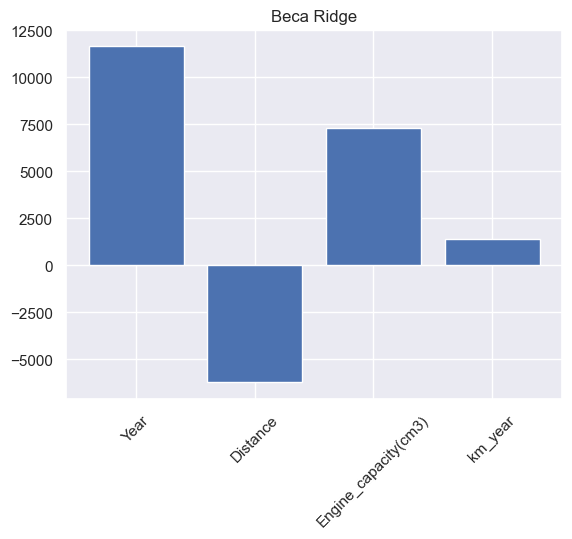

In [13]:
plt.bar(features_names, ridge.weights)
plt.title('Веса Ridge')
plt.xticks(rotation=45)
plt.show()

### Lasso (L1) регуляризация

L1 регуляризация может занулять некоторые веса, что помогает отбирать признаки.

In [14]:
class LassoRegression:
    def __init__(self, lr=0.5, l1_penalty=0.001, epochs=100):
        self.lr = lr
        self.l1_penalty = l1_penalty
        self.epochs = epochs
        self.cost = None

    def fit(self, X, y):
        weights = weights_init(X.shape[1])
        cost = np.zeros(self.epochs)
        for i in range(self.epochs):
            grad = np.zeros(weights.shape)
            loss = 0
            for m in range(X.shape[0]):
                yhat = forward(weights, X[m, :])
                grad += grad_loss(yhat, y[m], X[m, :])
                loss += loss_func(yhat, y[m])
            # L1 регуляризация: штраф за абсолютные значения весов
            l1_term = self.l1_penalty * np.sign(weights)
            weights = update_weights(grad / X.shape[0] + l1_term, weights, self.lr)
            cost[i] = loss / X.shape[0]
        self.weights = weights
        self.cost = cost

    def predict(self, X):
        return predict(self.weights, X)

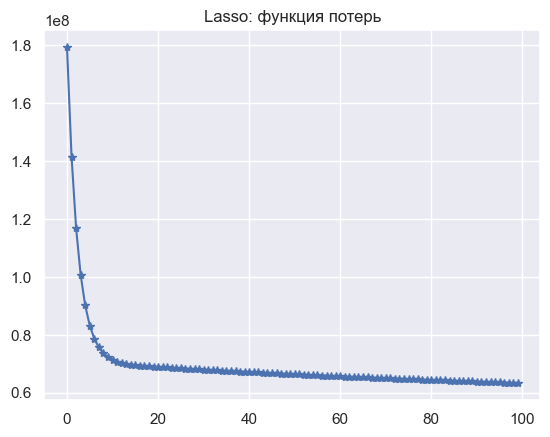

R2 Lasso: 0.28647847464669196


In [15]:
lasso = LassoRegression(lr=0.5, l1_penalty=0.01, epochs=100)
lasso.fit(X_train, y_train)
plt.plot(lasso.cost, '-*')
plt.title('Lasso: функция потерь')
plt.show()
print('R2 Lasso:', r2_score(lasso.weights, X_test, y_test))

### Визуализация весов Lasso

Проверьте, какие признаки были занулены.

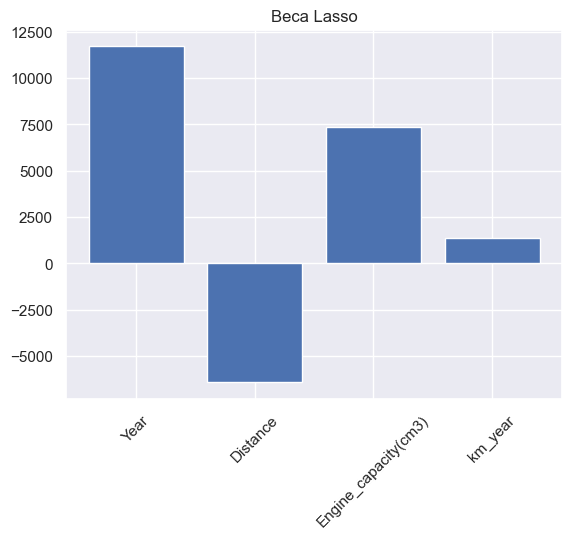

In [16]:
plt.bar(features_names, lasso.weights)
plt.title('Веса Lasso')
plt.xticks(rotation=45)
plt.show()

### ElasticNet регуляризация

ElasticNet сочетает преимущества L1 и L2, часто используется при большом количестве признаков.

In [17]:
class ElasticRegression:
    def __init__(self, lr=0.5, l1_penalty=0.001, l2_penalty=0.001, epochs=100):
        self.lr = lr
        self.l1_penalty = l1_penalty
        self.l2_penalty = l2_penalty
        self.epochs = epochs
        self.cost = None

    def fit(self, X, y):
        weights = weights_init(X.shape[1])
        cost = np.zeros(self.epochs)
        for i in range(self.epochs):
            grad = np.zeros(weights.shape)
            loss = 0
            for m in range(X.shape[0]):
                yhat = forward(weights, X[m, :])
                grad += grad_loss(yhat, y[m], X[m, :])
                loss += loss_func(yhat, y[m])
            # ElasticNet: объединяем штрафы L1 и L2
            l1_term = self.l1_penalty * np.sign(weights)
            l2_term = self.l2_penalty * weights
            weights = update_weights(grad / X.shape[0] + l1_term + l2_term, weights, self.lr)
            cost[i] = loss / X.shape[0]
        self.weights = weights
        self.cost = cost

    def predict(self, X):
        return predict(self.weights, X)

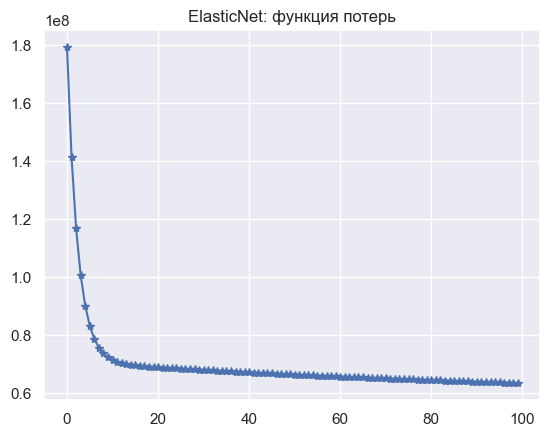

R2 ElasticNet: 0.28483773388979194


In [18]:
elastic = ElasticRegression(lr=0.5, l1_penalty=0.01, l2_penalty=0.001, epochs=100)
elastic.fit(X_train, y_train)
plt.plot(elastic.cost, '-*')
plt.title('ElasticNet: функция потерь')
plt.show()
print('R2 ElasticNet:', r2_score(elastic.weights, X_test, y_test))

### Визуализация весов ElasticNet

Сравните распределение весов с предыдущими моделями.

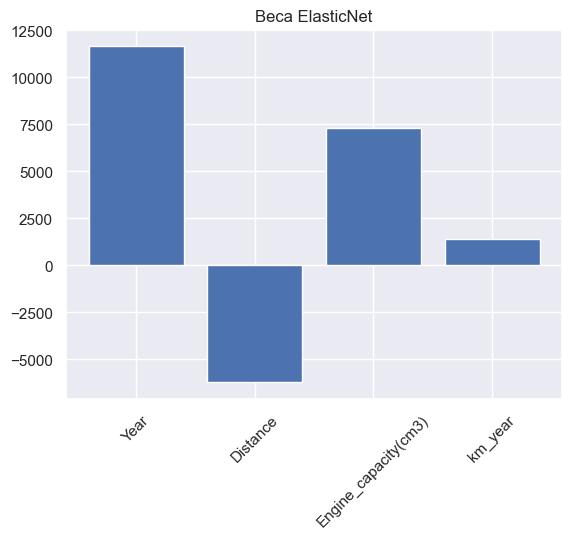

In [19]:
plt.bar(features_names, elastic.weights)
plt.title('Веса ElasticNet')
plt.xticks(rotation=45)
plt.show()

### Сравнение моделей

Сравните значения R2 для всех моделей, чтобы выбрать оптимальную регуляризацию для ваших данных.

In [20]:
print('R2 Ridge:', r2_score(ridge.weights, X_test, y_test))
print('R2 Lasso:', r2_score(lasso.weights, X_test, y_test))
print('R2 ElasticNet:', r2_score(elastic.weights, X_test, y_test))

R2 Ridge: 0.2848405402515326
R2 Lasso: 0.28647847464669196
R2 ElasticNet: 0.28483773388979194


# Контрольные вопросы

Ответьте на вопросы ниже, используя полученные данные.

Вопрос: Назовите число столбцов?

In [21]:
len(df.columns)

10

Вопрос: Назовите целевой столбец для задачи регрессии?

Ответ: `Price(euro)`

Вопрос: Назовите целевой столбец для задачи классификации?

Ответ: `Transmission`

Вопрос: Назовите колонку которую точно стоит убрать?

Ответ: `index`